In [4]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install nltk
!pip install scikit-learn

In [5]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization (used later)
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns if needed
pd.set_option("display.max_columns", None)

# Improve plot appearance
plt.style.use("ggplot")

In [6]:
# Load the complaint dataset
df = pd.read_csv("consumer_complaints.csv")

# Display first five rows
df.head()

C:\Users\epicr\AppData\Local\Temp\ipykernel_17640\3511365907.py:2: DtypeWarning: Columns (0: Consumer complaint narrative) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("consumer_complaints.csv")


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2023-03-24T04:36:20.000Z,Debt collection,Credit card debt,Took or threatened to take negative or legal a...,Collected or attempted to collect exempt funds,NaN,NaN,"Protas, Spivok & Collins. LLC",VA,22406,Servicemember,Web,2023-03-24T05:01:41.000Z,Closed with explanation,No,6747064.0
1,2024-02-26T22:23:15.000Z,Debt collection,Credit card debt,Took or threatened to take negative or legal a...,Sued you without properly notifying you of law...,NaN,NaN,"Protas, Spivok & Collins. LLC",VA,22042,NaN,Web,2024-03-04T18:31:15.000Z,Closed with explanation,No,8424458.0
2,2024-02-28T03:49:51.000Z,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",PR,00976,NaN,Web,2024-02-28T03:54:30.000Z,Closed with non-monetary relief,Yes,8434350.0
3,2024-02-28T03:47:32.000Z,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,PR,00976,NaN,Web,2024-02-28T03:53:46.000Z,Closed with explanation,Yes,8434243.0
4,2024-04-13T04:08:31.000Z,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"EQUIFAX, INC.",PR,00976,NaN,Web,2024-04-13T04:14:18.000Z,Closed with non-monetary relief,Yes,8758513.0


In [7]:
# Dataset dimensions
print("Shape:", df.shape)

# Column names
print(df.columns)

# Data types
df.info()

# Summary statistics
df.describe(include="all")

Shape: (16505480, 16)
Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Submitted via', 'Date sent to company',
       'Company response to consumer', 'Timely response?', 'Complaint ID'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 16505480 entries, 0 to 16505479
Data columns (total 16 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Date received                 str    
 1   Product                       str    
 2   Sub-product                   str    
 3   Issue                         str    
 4   Sub-issue                     str    
 5   Consumer complaint narrative  str    
 6   Company public response       str    
 7   Company                       str    
 8   State                         str    
 9   ZIP code                      str    
 10  Tags                          st

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
count,16505480,16504424,16269079,16504305,15581871,3812958,8814426,16505480,16442152,16502617,779220,16505406,16452236,16239560,16505480,1.649260e+07
unique,977083,23,87,180,274,2562097,11,8032,63,36439,3,6,950024,8,2,NaN
top,2025-01-17,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,In accordance with the Fair Credit Reporting a...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",FL,XXXXX,Servicemember,Web,2025-09-11,Closed with explanation,Yes,NaN
freq,34088,11029024,13128356,7308115,4775712,27510,8458292,4418425,2255172,137556,495635,15872329,49538,9895709,16402727,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.264846e+07
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.368468e+06
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.595647e+06
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.250283e+07
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.797029e+07


In [8]:
columns_needed = [
    "Date received",
    "Product",
    "Issue",
    "Consumer complaint narrative",
    "Company",
    "State",
    "Submitted via",
    "Company response to consumer",
    "Timely response?"
]

df = df[columns_needed]

In [9]:
# Count missing values
missing = df.isnull().sum()

print(missing)

Date received                          0
Product                             1056
Issue                               1175
Consumer complaint narrative    12692522
Company                                0
State                              63328
Submitted via                         74
Company response to consumer      265920
Timely response?                       0
dtype: int64


In [10]:
# Remove rows missing essential information
df = df.dropna(subset=[
    "Consumer complaint narrative",
    "Product"
])

# Fill remaining missing values
df["State"] = df["State"].fillna("Unknown")
df["Company response to consumer"] = (
    df["Company response to consumer"]
      .fillna("Not Available")
)
df["Submitted via"] = df["Submitted via"].fillna("Unknown")

In [11]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("New shape:", df.shape)

Duplicate rows: 250797
New shape: (3562161, 9)


In [12]:
# Convert to datetime format
df["Date received"] = pd.to_datetime(
    df["Date received"],
    errors="coerce"
)

# Remove invalid dates
df = df.dropna(subset=["Date received"])

In [13]:
print(df.info())

print("\nRemaining Missing Values:")
print(df.isnull().sum())

print("\nFinal Dataset Shape:")
print(df.shape)

df.head()

<class 'pandas.DataFrame'>
Index: 17206 entries, 13 to 1189390
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype              
---  ------                        --------------  -----              
 0   Date received                 17206 non-null  datetime64[us, UTC]
 1   Product                       17206 non-null  str                
 2   Issue                         17206 non-null  str                
 3   Consumer complaint narrative  17206 non-null  str                
 4   Company                       17206 non-null  str                
 5   State                         17206 non-null  str                
 6   Submitted via                 17206 non-null  str                
 7   Company response to consumer  17206 non-null  str                
 8   Timely response?              17206 non-null  str                
dtypes: datetime64[us, UTC](1), str(8)
memory usage: 1.3 MB
None

Remaining Missing Values:
Date received                   

,Date received,Product,Issue,Consumer complaint narrative,Company,State,Submitted via,Company response to consumer,Timely response?
13,2024-08-23 19:32:05+00:00,Mortgage,Applying for a mortgage or refinancing an exis...,"1. Inflated Appraisal by XXXX, XXXX Rocket Mor...","Rocket Mortgage, LLC",GA,Web,Closed with explanation,Yes
14,2024-09-10 17:35:19+00:00,Checking or savings account,Managing an account,I deposited XXXX separate checks via chase mob...,JPMORGAN CHASE & CO.,NV,Web,Closed with explanation,Yes
19,2024-11-20 19:29:13+00:00,Debt collection,Took or threatened to take negative or legal a...,On XX/XX/XXXX virtiouso sourcing called me abo...,"VIRTUOSO SOURCING GROUP, LLC.",MO,Web,Closed with explanation,No
21,2025-01-25 23:39:04+00:00,Debt collection,Written notification about debt,I am writing to file a complaint regarding my ...,"Protas, Spivok & Collins. LLC",MD,Web,Closed with explanation,No
22,2025-02-06 19:50:15+00:00,Debt collection,Took or threatened to take negative or legal a...,"On XX/XX/XXXX, I made a payment via the Protas...","Protas, Spivok & Collins. LLC",VA,Web,Closed with explanation,No


In [14]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download resources (run once)
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\epicr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\epicr\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\epicr\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [15]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [16]:
def clean_text(text):
    """
    Cleans complaint text for NLP analysis.
    """

    # Handle missing values
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatize
    words = [lemmatizer.lemmatize(word) for word in words]

    # Join words back into a sentence
    return " ".join(words)

In [17]:
df["cleaned_text"] = df["Consumer complaint narrative"].apply(clean_text)

In [18]:
df[
    [
        "Consumer complaint narrative",
        "cleaned_text"
    ]
].head()

,Consumer complaint narrative,cleaned_text
13,"1. Inflated Appraisal by XXXX, XXXX Rocket Mor...",inflated appraisal xxxx xxxx rocket mortgage a...
14,I deposited XXXX separate checks via chase mob...,deposited xxxx separate check via chase mobile...
19,On XX/XX/XXXX virtiouso sourcing called me abo...,xxxxxxxx virtiouso sourcing called debt believ...
21,I am writing to file a complaint regarding my ...,writing file complaint regarding debt xxxx xxx...
22,"On XX/XX/XXXX, I made a payment via the Protas...",xxxxxxxx made payment via protas spivok collin...


In [19]:
# Basic dataset summary
print("Number of complaints:", len(df))
print("Number of unique products:", df["Product"].nunique())
print("Number of companies:", df["Company"].nunique())
print("Number of states:", df["State"].nunique())

Number of complaints: 17206
Number of unique products: 12
Number of companies: 1094
Number of states: 58


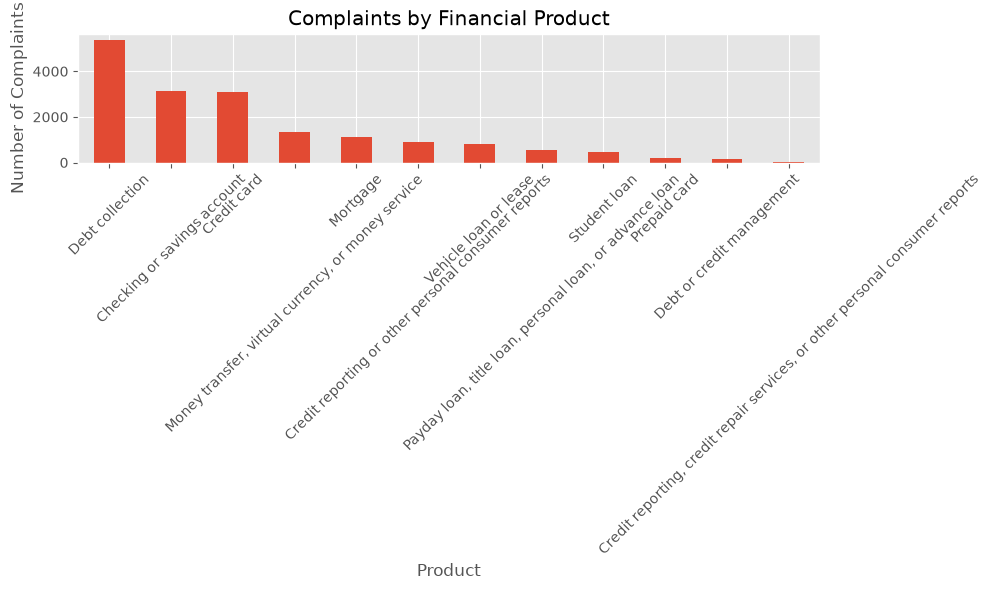

In [20]:
product_counts = (
    df["Product"]
      .value_counts()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

product_counts.plot(kind="bar")

plt.title("Complaints by Financial Product")
plt.xlabel("Product")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

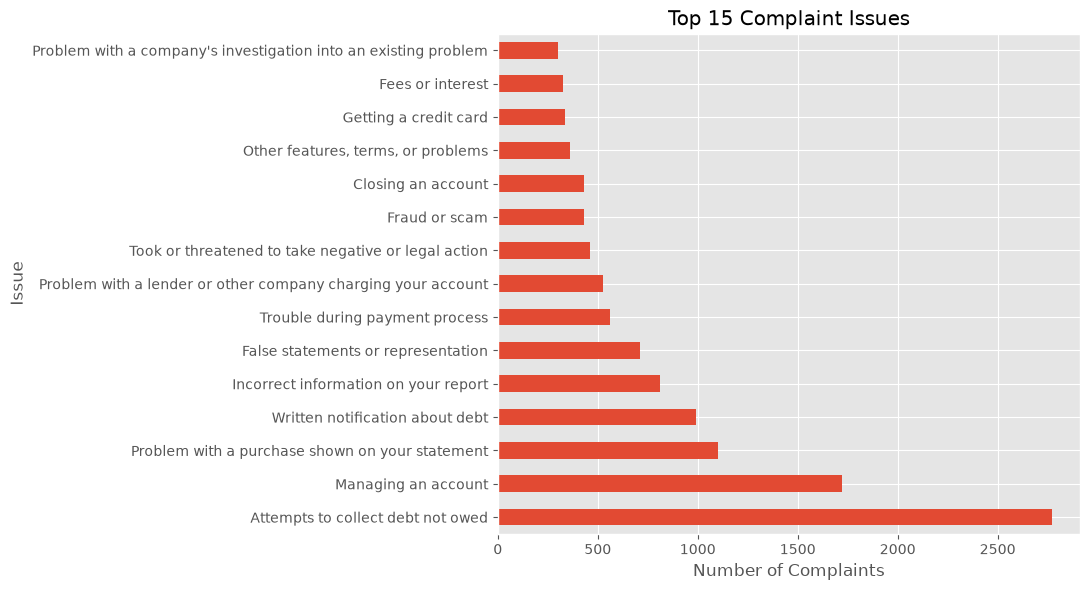

In [21]:
issue_counts = (
    df["Issue"]
      .value_counts()
      .head(15)
)

plt.figure(figsize=(11,6))

issue_counts.plot(kind="barh")

plt.title("Top 15 Complaint Issues")
plt.xlabel("Number of Complaints")

plt.tight_layout()
plt.show()

In [22]:
df["Date received"] = pd.to_datetime(
    df["Date received"],
    errors="coerce"
)

In [23]:
monthly = (
    df
    .set_index("Date received")
    .resample("ME")   # Month End
    .size()
)

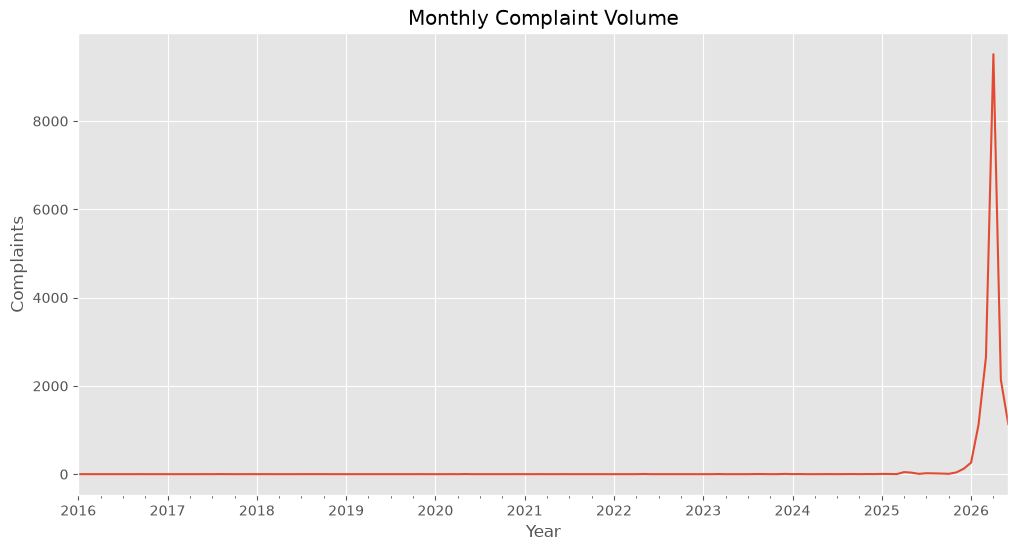

In [24]:
plt.figure(figsize=(12,6))

monthly.plot()

plt.title("Monthly Complaint Volume")

plt.xlabel("Year")

plt.ylabel("Complaints")

plt.show()

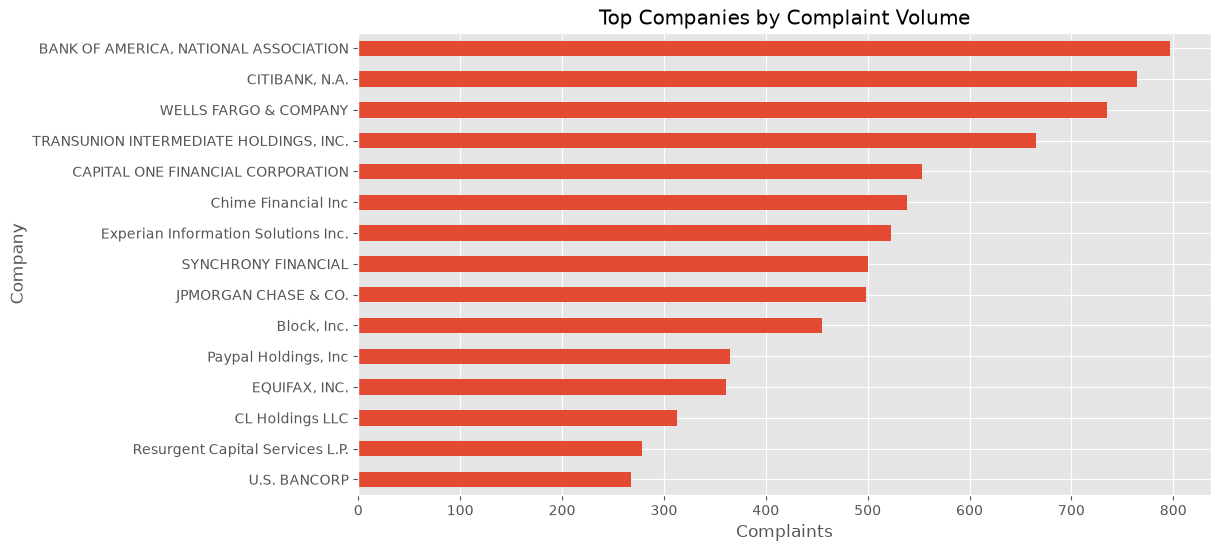

In [25]:
top_companies = (
    df["Company"]
      .value_counts()
      .head(15)
)

plt.figure(figsize=(11,6))

top_companies.sort_values().plot(kind="barh")

plt.title("Top Companies by Complaint Volume")

plt.xlabel("Complaints")

plt.show()

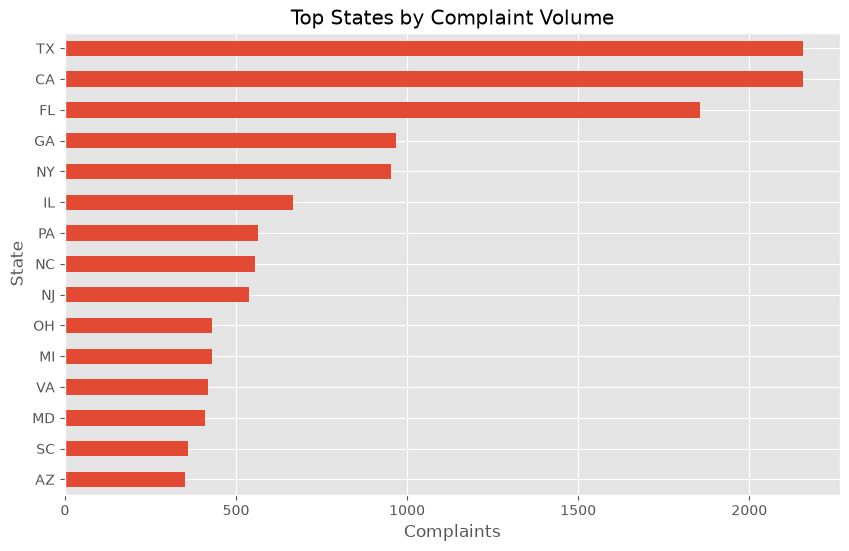

In [26]:
top_states = (
    df["State"]
      .value_counts()
      .head(15)
)

plt.figure(figsize=(10,6))

top_states.sort_values().plot(kind="barh")

plt.title("Top States by Complaint Volume")

plt.xlabel("Complaints")

plt.show()

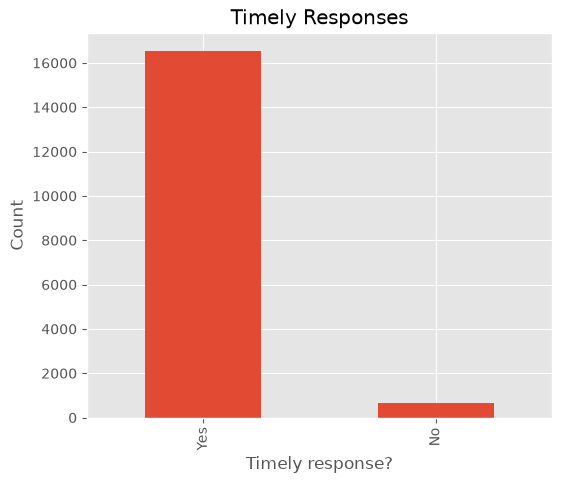

In [27]:
response = (
    df["Timely response?"]
      .value_counts()
)

plt.figure(figsize=(6,5))

response.plot(kind="bar")

plt.title("Timely Responses")

plt.ylabel("Count")

plt.show()

In [28]:
cross_tab = pd.crosstab(
    df["Product"],
    df["Timely response?"]
)

cross_tab

Timely response?,No,Yes
Product,,
Checking or savings account,43,3097
Credit card,40,3072
Credit reporting or other personal consumer reports,38,879
"Credit reporting, credit repair services, or other personal consumer reports",0,14
Debt collection,185,5202
Debt or credit management,16,124
"Money transfer, virtual currency, or money service",62,1266
Mortgage,19,1104
"Payday loan, title loan, personal loan, or advance loan",34,516


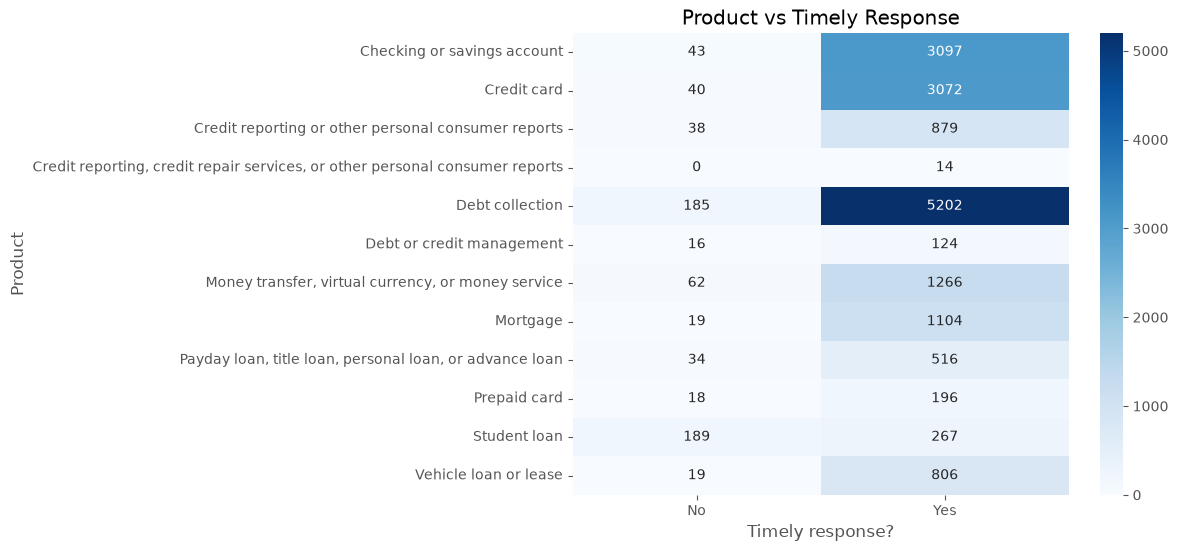

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cross_tab,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Product vs Timely Response")

plt.show()

In [30]:
product_counts.to_csv("product_summary.csv")

issue_counts.to_csv("issue_summary.csv")

monthly.to_csv("monthly_trends.csv")

In [31]:
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [32]:
# Features (cleaned complaint text)
X = df["cleaned_text"]

# Target variable
y = df["Product"]

In [33]:
print(type(y))
print(y.dtype)

print(y.isna().sum())
print(y.value_counts(dropna=False))

<class 'pandas.Series'>
str
0
Product
Debt collection                                                                 5387
Checking or savings account                                                     3140
Credit card                                                                     3112
Money transfer, virtual currency, or money service                              1328
Mortgage                                                                        1123
Credit reporting or other personal consumer reports                              917
Vehicle loan or lease                                                            825
Payday loan, title loan, personal loan, or advance loan                          550
Student loan                                                                     456
Prepaid card                                                                     214
Debt or credit management                                                        140
Credit reporting, credit re

In [35]:
print(X.isna().sum().sum())

0


In [36]:
mask = y.notna()
X = X.loc[mask]
y = y.loc[mask]

In [37]:
print(y.value_counts()[y.value_counts() < 2])

Series([], Name: count, dtype: int64)


In [38]:
counts = y.value_counts()
valid_classes = counts[counts >= 2].index

mask = y.isin(valid_classes)
X = X.loc[mask]
y = y.loc[mask]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=20
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [44]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [45]:
y_pred = model.predict(X_test_tfidf)

In [46]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.799


In [47]:
print(classification_report(y_test, y_pred))

                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       0.73      0.82      0.77       628
                                                                 Credit card       0.76      0.81      0.79       622
                         Credit reporting or other personal consumer reports       0.78      0.68      0.73       183
Credit reporting, credit repair services, or other personal consumer reports       0.00      0.00      0.00         3
                                                             Debt collection       0.83      0.95      0.89      1078
                                                   Debt or credit management       1.00      0.04      0.07        28
                          Money transfer, virtual currency, or money service       0.77      0.55      0.64       266
                                                       

C:\Users\epicr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\epicr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\epicr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [48]:
cm = confusion_matrix(y_test, y_pred)

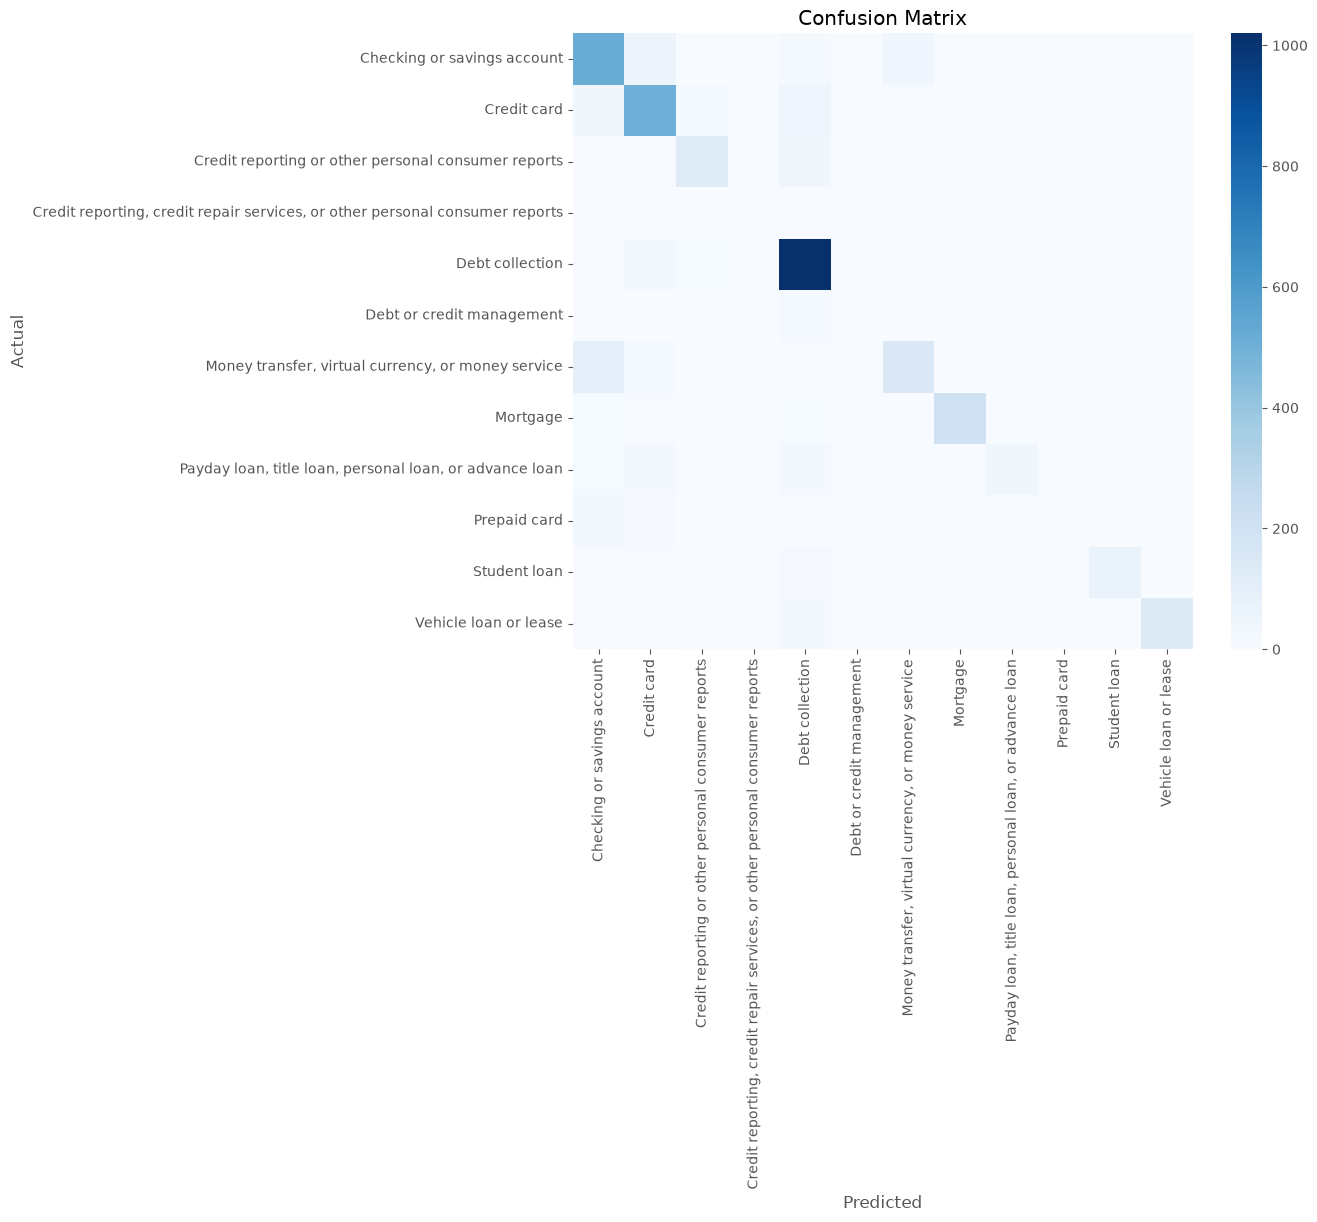

In [49]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [50]:
feature_names = tfidf.get_feature_names_out()

for i, product in enumerate(model.classes_):
    top_features = model.coef_[i].argsort()[-10:][::-1]
    print(f"\nTop words for: {product}")
    print([feature_names[j] for j in top_features])


Top words for: Checking or savings account
['bank', 'account', 'fund', 'chime', 'debit', 'deposit', 'checking', 'branch', 'debit card', 'transaction']

Top words for: Credit card
['credit card', 'card', 'credit', 'charge', 'synchrony', 'citi', 'interest', 'citibank', 'barclays', 'bilt']

Top words for: Credit reporting or other personal consumer reports
['xxxx xxxx', 'inquiry', 'credit report', 'mohela', 'report', 'equifax', 'transunion', 'entry', 'late', 'credit']

Top words for: Credit reporting, credit repair services, or other personal consumer reports
['following item', 'reinvestigate', 'item xxxx', 'dept', 'education', 'xxxx xxxx', 'item', 'section', 'usc section', 'xxxx']

Top words for: Debt collection
['debt', 'collection', 'validation', 'owe', 'owed', 'credit', 'apartment', 'collector', 'collect', 'original creditor']

Top words for: Debt or credit management
['program', 'debt', 'settlement', 'experian', 'fee', 'enrolled', 'creditor', 'credit', 'score', 'negotiation']

Top w

In [51]:
# Ensure the date column is datetime
df["Date received"] = pd.to_datetime(df["Date received"])

# Create time-based features
df["Year"] = df["Date received"].dt.year
df["Month"] = df["Date received"].dt.month
df["Month_Name"] = df["Date received"].dt.month_name()
df["Quarter"] = df["Date received"].dt.quarter

In [52]:
monthly_trend = (
    df.groupby(["Year", "Month"])
      .size()
      .reset_index(name="Complaints")
)

monthly_trend.head()

,Year,Month,Complaints
0,2016,1,1
1,2016,9,1
2,2017,6,1
3,2017,8,2
4,2017,9,1


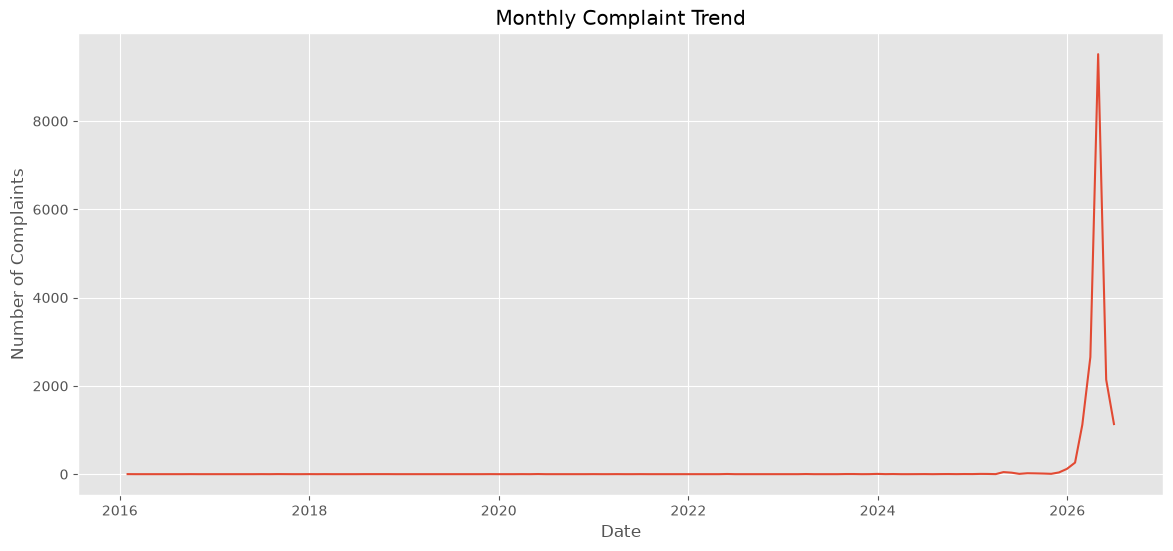

In [54]:
plt.figure(figsize=(14,6))

plt.plot(
    df.set_index("Date received")
      .resample("ME")
      .size()
)

plt.title("Monthly Complaint Trend")
plt.xlabel("Date")
plt.ylabel("Number of Complaints")

plt.show()

In [55]:
quarterly = (
    df.groupby(["Year", "Quarter"])
      .size()
      .reset_index(name="Complaints")
)

quarterly

,Year,Quarter,Complaints
0,2016,1,1
1,2016,3,1
2,2017,2,1
3,2017,3,3
4,2017,4,1
5,2018,1,1
6,2018,3,3
7,2018,4,1
8,2019,4,1
9,2020,1,1


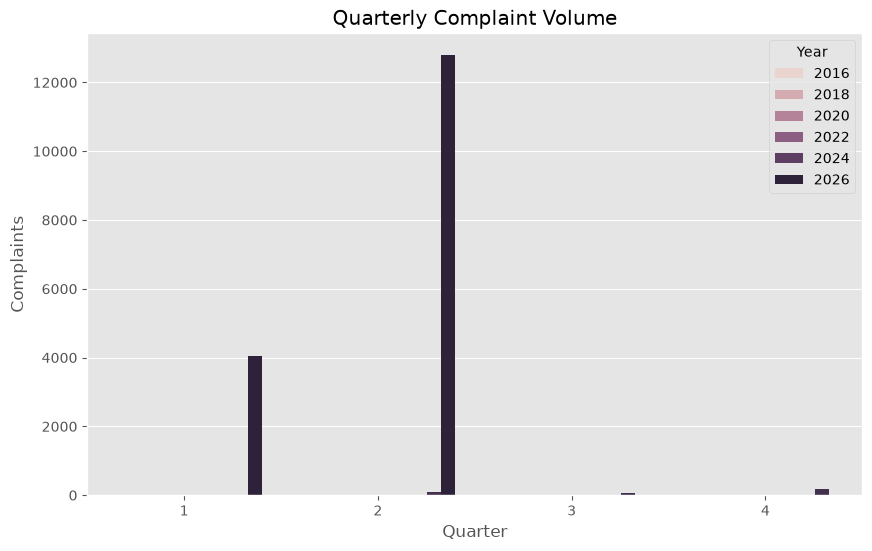

In [56]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=quarterly,
    x="Quarter",
    y="Complaints",
    hue="Year"
)

plt.title("Quarterly Complaint Volume")

plt.show()

In [57]:
monthly_avg = (
    df.groupby("Month_Name")
      .size()
      .reindex([
          "January","February","March",
          "April","May","June",
          "July","August","September",
          "October","November","December"
      ])
)

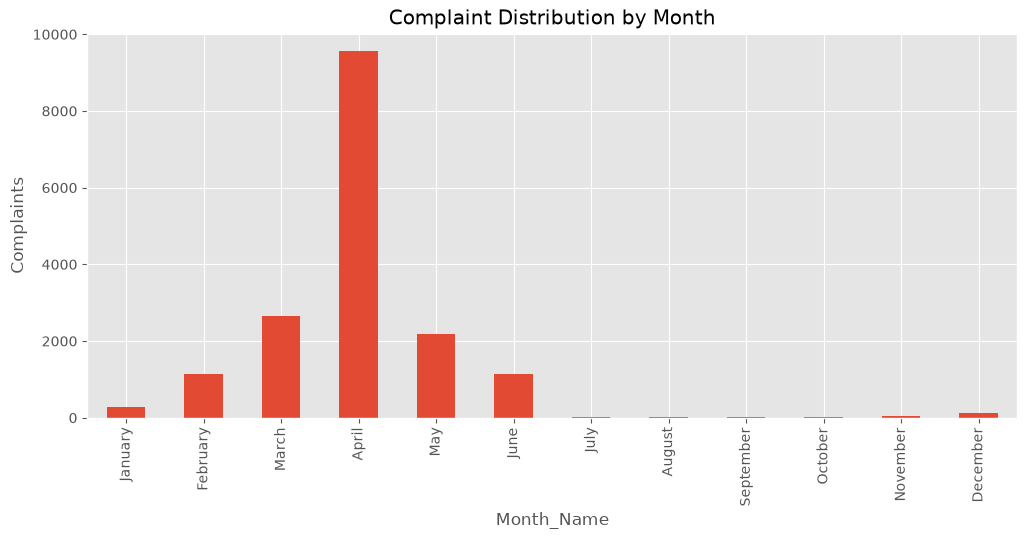

In [58]:
plt.figure(figsize=(12,5))

monthly_avg.plot(kind="bar")

plt.title("Complaint Distribution by Month")

plt.ylabel("Complaints")

plt.show()

In [60]:
product_trend = (
    df.groupby([
        pd.Grouper(
            key="Date received",
            freq="YE"
        ),
        "Product"
    ])
    .size()
    .unstack(fill_value=0)
)

product_trend.head()

Product,Checking or savings account,Credit card,Credit reporting or other personal consumer reports,"Credit reporting, credit repair services, or other personal consumer reports",Debt collection,Debt or credit management,"Money transfer, virtual currency, or money service",Mortgage,"Payday loan, title loan, personal loan, or advance loan",Prepaid card,Student loan,Vehicle loan or lease
Date received,,,,,,,,,,,,
2016-12-31 00:00:00+00:00,0,0,0,0,2,0,0,0,0,0,0,0
2017-12-31 00:00:00+00:00,1,0,0,1,3,0,0,0,0,0,0,0
2018-12-31 00:00:00+00:00,1,0,0,0,3,0,0,1,0,0,0,0
2019-12-31 00:00:00+00:00,0,0,0,0,1,0,0,0,0,0,0,0
2020-12-31 00:00:00+00:00,0,0,0,3,1,0,1,0,0,0,0,0


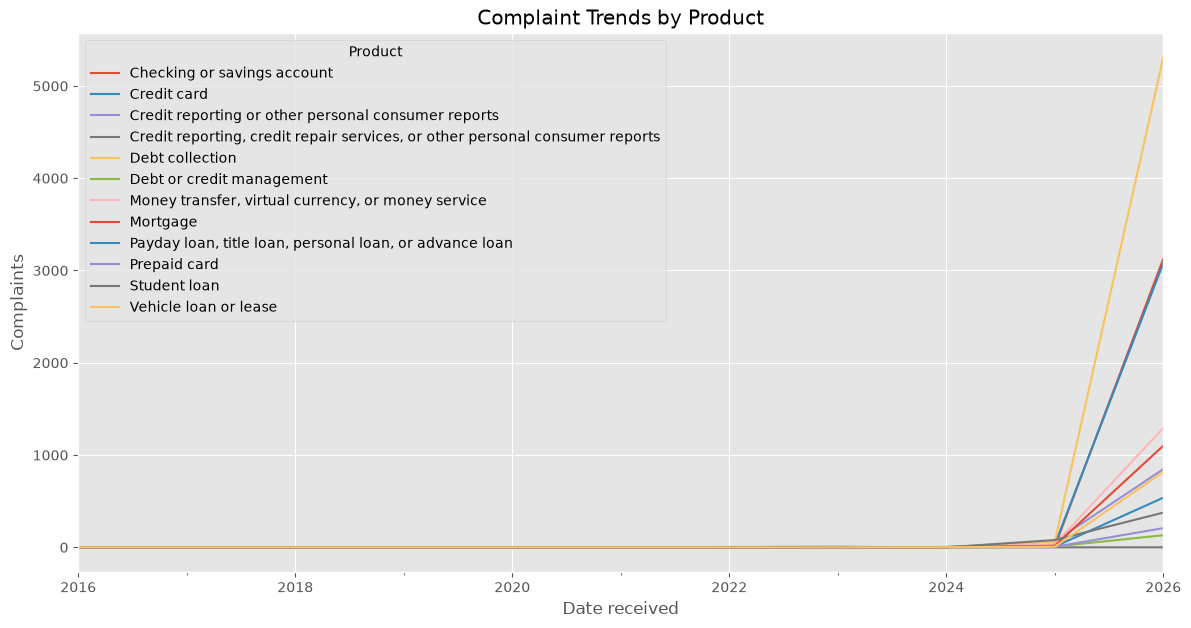

In [61]:
product_trend.plot(
    figsize=(14,7)
)

plt.title("Complaint Trends by Product")

plt.ylabel("Complaints")

plt.show()

In [63]:
issue_trend = (
    df.groupby([
        pd.Grouper(
            key="Date received",
            freq="YE"
        ),
        "Issue"
    ])
    .size()
    .reset_index(name="Count")
)

In [64]:
top_issues = (
    df["Issue"]
      .value_counts()
      .head(5)
      .index
)

filtered = issue_trend[
    issue_trend["Issue"].isin(top_issues)
]

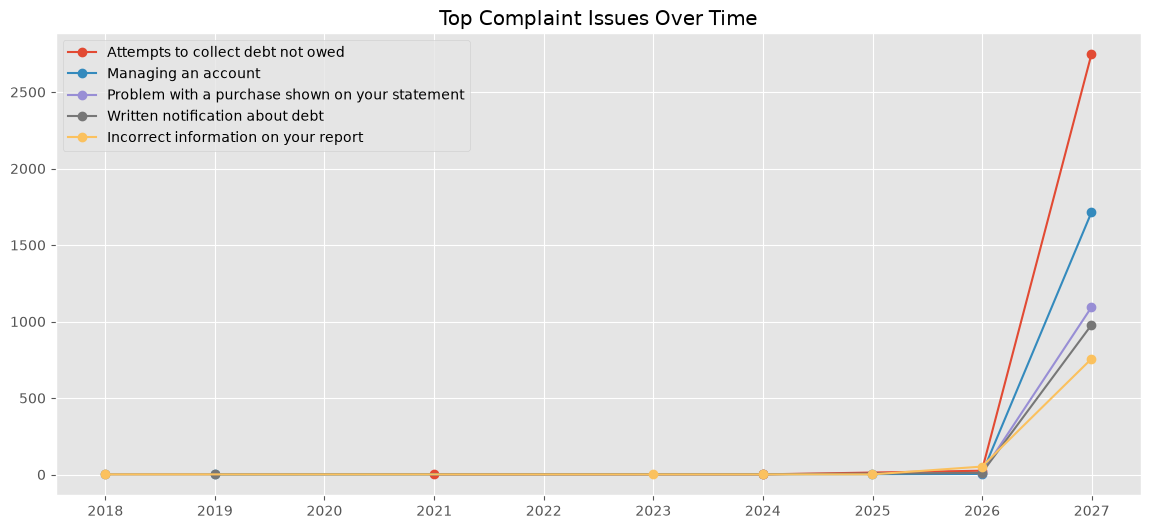

In [65]:
plt.figure(figsize=(14,6))

for issue in top_issues:
    temp = filtered[
        filtered["Issue"] == issue
    ]

    plt.plot(
        temp["Date received"],
        temp["Count"],
        marker="o",
        label=issue
    )

plt.legend()

plt.title("Top Complaint Issues Over Time")

plt.show()

In [66]:
yearly = (
    df.groupby("Year")
      .size()
      .reset_index(name="Complaints")
)

yearly["Growth_%"] = (
    yearly["Complaints"]
          .pct_change()
          * 100
)

yearly

,Year,Complaints,Growth_%
0,2016,2,NaN
1,2017,5,150.000000
2,2018,5,0.000000
3,2019,1,-80.000000
4,2020,5,400.000000
5,2021,2,-60.000000
6,2022,4,100.000000
7,2023,16,300.000000
8,2024,18,12.500000
9,2025,321,1683.333333


In [67]:
monthly_trend.to_csv(
    "monthly_trend.csv",
    index=False
)

quarterly.to_csv(
    "quarterly_trend.csv",
    index=False
)

yearly.to_csv(
    "yearly_growth.csv",
    index=False
)

In [68]:
# Transform all cleaned complaint text
X_all_tfidf = tfidf.transform(df["cleaned_text"])

# Predict product category
df["Predicted_Product"] = model.predict(X_all_tfidf)

In [69]:
# Predict probabilities
probabilities = model.predict_proba(X_all_tfidf)

# Maximum probability for each prediction
df["Prediction_Confidence"] = probabilities.max(axis=1)

In [70]:
final_columns = [
    "Date received",
    "Year",
    "Quarter",
    "Month",
    "Month_Name",
    "State",
    "Company",
    "Product",
    "Predicted_Product",
    "Prediction_Confidence",
    "Issue",
    "Submitted via",
    "Timely response?",
    "Company response to consumer",
    "Consumer complaint narrative",
    "cleaned_text"
]

df_final = df[final_columns]

In [71]:
print(df_final.info())

print(df_final.head())

print(df_final.isnull().sum())

<class 'pandas.DataFrame'>
Index: 17206 entries, 13 to 1189390
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype              
---  ------                        --------------  -----              
 0   Date received                 17206 non-null  datetime64[us, UTC]
 1   Year                          17206 non-null  int32              
 2   Quarter                       17206 non-null  int32              
 3   Month                         17206 non-null  int32              
 4   Month_Name                    17206 non-null  str                
 5   State                         17206 non-null  str                
 6   Company                       17206 non-null  str                
 7   Product                       17206 non-null  str                
 8   Predicted_Product             17206 non-null  str                
 9   Prediction_Confidence         17206 non-null  float64            
 10  Issue                         17206 non-null  s

In [72]:
df_final.to_csv(
    "banking_complaints_cleaned.csv",
    index=False
)

print("Dataset exported successfully!")

Dataset exported successfully!


In [73]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "model_performance.csv"
)

C:\Users\epicr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\epicr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\epicr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [74]:
# Product summary
product_summary = (
    df.groupby("Product")
      .size()
      .reset_index(name="Complaints")
)

product_summary.to_csv(
    "product_summary.csv",
    index=False
)

In [75]:
# Monthly trend
monthly_summary = (
    df.groupby(["Year", "Month"])
      .size()
      .reset_index(name="Complaints")
)

monthly_summary.to_csv(
    "monthly_summary.csv",
    index=False
)

In [76]:
# Company summary
company_summary = (
    df.groupby("Company")
      .size()
      .reset_index(name="Complaints")
      .sort_values(
          "Complaints",
          ascending=False
      )
)

company_summary.to_csv(
    "company_summary.csv",
    index=False
)